## Statistics

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import scipy.stats as stats
from scipy.stats import chi2_contingency
from scipy.stats import shapiro
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from statsmodels.stats.weightstats import ztest
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
from scipy import stats


# Tufte-style visuals
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

def tufte_plot(ax, title, xlabel, ylabel):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_prop_cycle(color=sns.color_palette("deep"))
    return ax

In [2]:
df = pd.read_csv("Optimized_data.csv")

### Descriptive Statistics

In [3]:
# Numeric summary
num_summary = df.describe()
print("Numeric Summary:", num_summary)

# Categorical overview 
cat_summary = {
    'Country_count': df['Country'].nunique()
}
print("Categorical Summary:", cat_summary)


Numeric Summary:              Year  Population (People)  GDP-PPP (Million Intl$ (2011))  \
count  4825.00000         4.825000e+03                    4.825000e+03   
mean   2002.00000         6.741062e+07                    7.976519e+05   
std       7.21185         4.681587e+08                    5.365802e+06   
min    1990.00000         9.003000e+03                    2.133303e+01   
25%    1996.00000         1.850527e+06                    1.095579e+04   
50%    2002.00000         7.152385e+06                    3.988737e+04   
75%    2008.00000         2.186593e+07                    2.270205e+05   
max    2014.00000         7.268986e+09                    1.022958e+08   

       Total Fuel Consumption (ktoe)  
count                    4825.000000  
mean                    86002.440000  
std                     17630.539732  
min                     58467.000000  
25%                     67230.000000  
50%                     93479.000000  
75%                     99183.000000  
max 

By summarizing the sample’s central tendency and variability, I can construct confidence intervals around each mean to infer the true population parameters—laying the groundwork for hypothesis tests on feature effects.

Knowing the number of distinct groups allows us to plan ANOVA or chi‑square tests

### Measures of central tendency 

In [4]:
# Mean for all numerical columns
numerical_means = df.mean(numeric_only=True)

print(round(numerical_means))    

Year                                  2002.0
Population (People)               67410624.0
GDP-PPP (Million Intl$ (2011))      797652.0
Total Fuel Consumption (ktoe)        86002.0
dtype: float64


These sample means serve as point estimates; I use their standard errors to build confidence intervals and test whether observed mean differences across years

In [6]:
# Mode for all numerical columns
numerical_modes = df.select_dtypes(include='number').mode().round()

print(numerical_modes)


    Year  Population (People)  GDP-PPP (Million Intl$ (2011))  \
0   1990            7152385.0                         39887.0   
1   1991                  NaN                             NaN   
2   1992                  NaN                             NaN   
3   1993                  NaN                             NaN   
4   1994                  NaN                             NaN   
5   1995                  NaN                             NaN   
6   1996                  NaN                             NaN   
7   1997                  NaN                             NaN   
8   1998                  NaN                             NaN   
9   1999                  NaN                             NaN   
10  2000                  NaN                             NaN   
11  2001                  NaN                             NaN   
12  2002                  NaN                             NaN   
13  2003                  NaN                             NaN   
14  2004                 

In [11]:
# Minimum values for all numerical columns
numerical_min = df.min(numeric_only=True)

print(round(numerical_min))


Year                               1990.0
Population (People)                9003.0
GDP-PPP (Million Intl$ (2011))       21.0
Total Fuel Consumption (ktoe)     58467.0
dtype: float64


In [12]:
# Maximum values for all numerical columns
numerical_max = df.max(numeric_only=True)

print(round(numerical_max))

Year                              2.014000e+03
Population (People)               7.268986e+09
GDP-PPP (Million Intl$ (2011))    1.022958e+08
Total Fuel Consumption (ktoe)     1.112640e+05
dtype: float64


In [13]:
# Standard Deviation values for all numerical columns
numerical_std = df.std(numeric_only=True)

# Display the result
print(round(numerical_std))

Year                                      7.0
Population (People)               468158737.0
GDP-PPP (Million Intl$ (2011))      5365802.0
Total Fuel Consumption (ktoe)         17631.0
dtype: float64


Mean, median, std.dev help assess central tendency

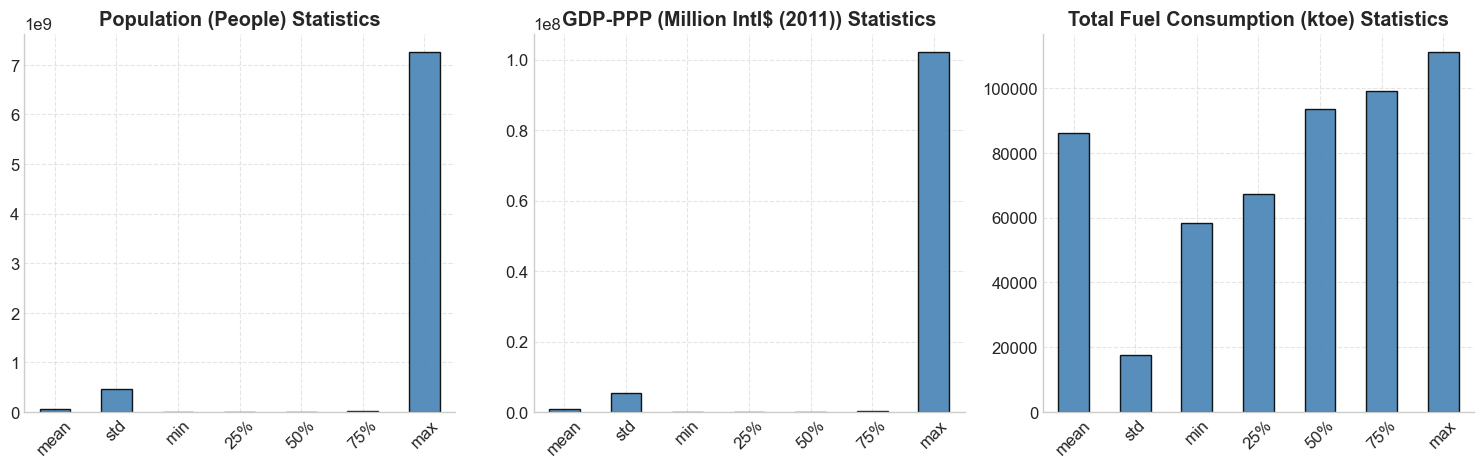

In [15]:
numeric_cols = [col for col in df.select_dtypes('number').columns if col != 'Year']
n_cols = len(numeric_cols)

# Create subplots (adjust figsize depending on how many columns you have)
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))

if n_cols == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_cols):
    stats = df[col].describe().drop('count')
    stats.plot.bar(ax=ax, color='steelblue', edgecolor='k', alpha=0.9)
    [ax.spines[s].set_visible(False) for s in ['top', 'right']]
    ax.set_title(f'{col} Statistics', weight='bold')
    ax.grid(ls='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# plt.savefig('describe.png')
# plt.close()

These plots highlight variables having large variance or large skew if taken per variable so can be used to select those features that might violate the assumptions underlying normality and should thus be addressed by nonparametric methods.

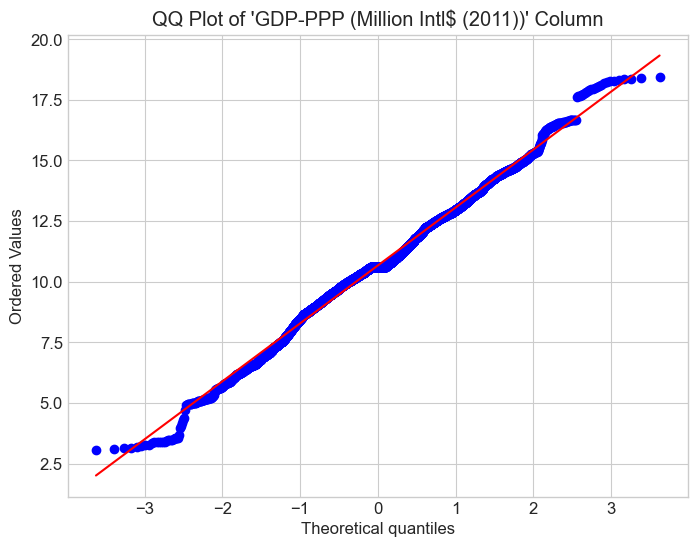

In [17]:
import scipy.stats as stats
df_log = np.log(df['GDP-PPP (Million Intl$ (2011))'])
# Plot QQ plot
plt.figure(figsize=(8, 6))
stats.probplot(df_log, dist="norm", plot=plt)
plt.title("QQ Plot of 'GDP-PPP (Million Intl$ (2011))' Column")
plt.show()

The QQ plot for the log-transformed GDP-PPP has points clustered around the red reference line for the central quantiles, indicating that the bulk of the data is indeed normally distributed. However, the departure from the line on either tail denotes heavier tails than a true normal: when applying inferential methods stipulating true normality on extreme values.

Distributions of Key Numeric Attributes


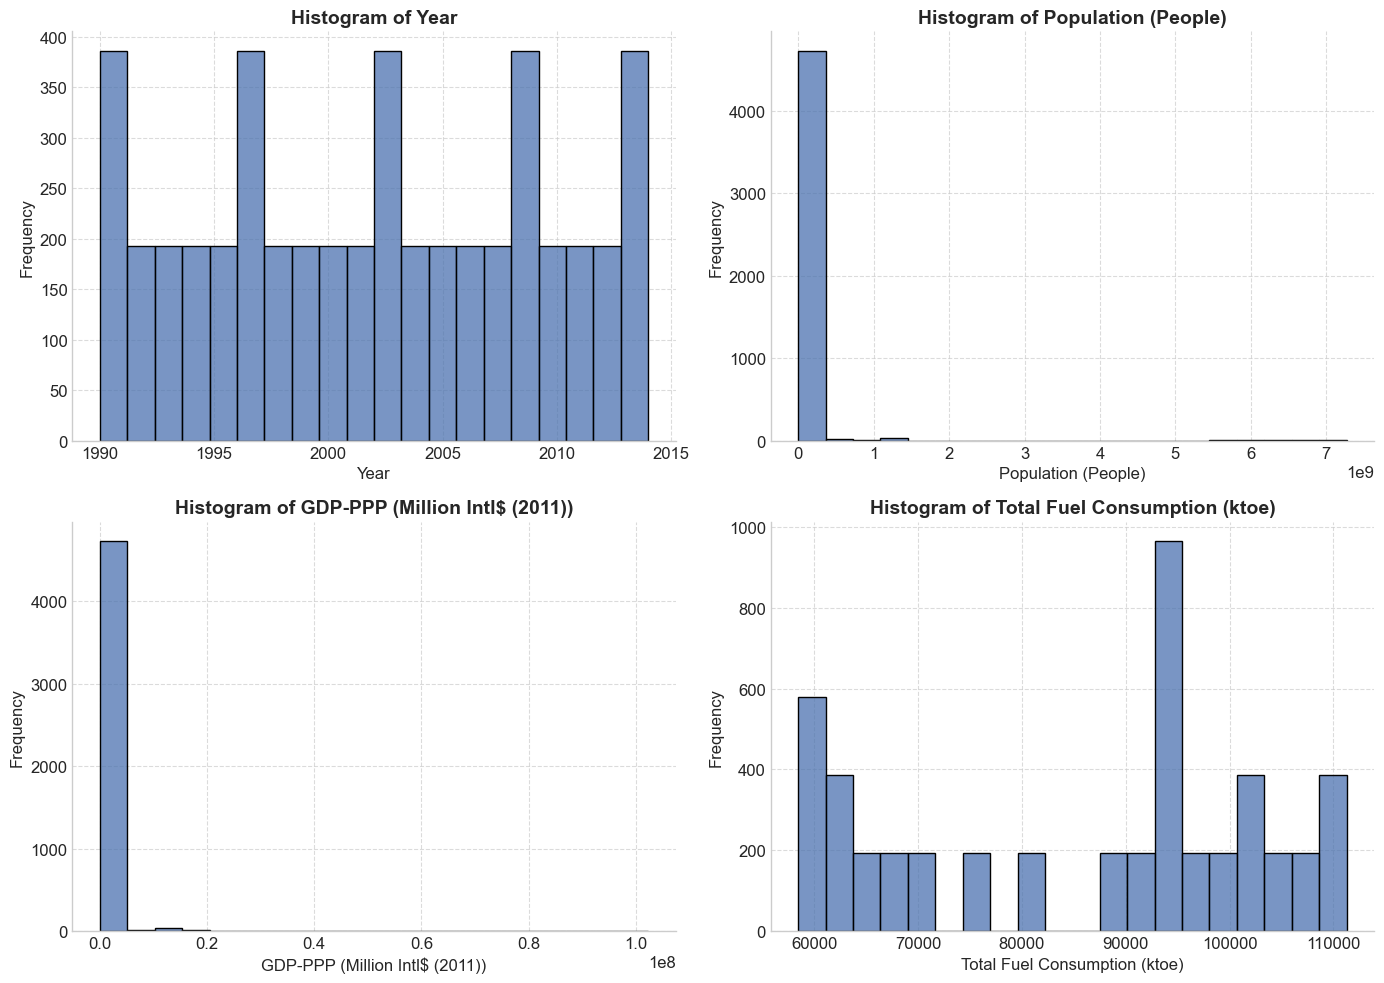

In [19]:
print("Distributions of Key Numeric Attributes")
numeric_cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))  
axes = axes.flatten() 

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=20, edgecolor='black', ax=axes[i])
    axes[i] = tufte_plot(axes[i], f'Histogram of {col}', col, 'Frequency')

plt.tight_layout()
plt.show()


This code generates histograms to visualize the distributions of key numeric columns in the DataFrame df.

It selects numeric columns, sets up a 2x2 grid of subplots, and plots each using Seaborn for clear visuals, it plots a histogram using Seaborn and applies the `tufte_plot` styling for a clean, readable layout. 


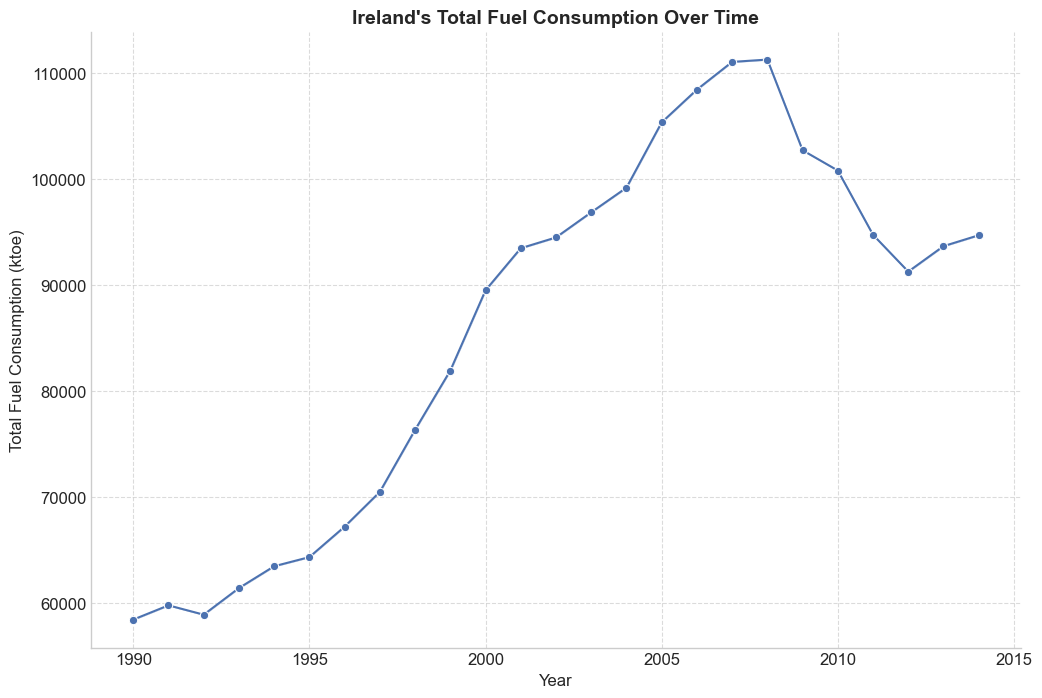

In [21]:
fig, ax = plt.subplots()
sns.lineplot(x='Year', y='Total Fuel Consumption (ktoe)', marker='o', data=df, ax=ax)

# Apply the Tufte-style formatting
tufte_plot(ax,
           title="Ireland's Total Fuel Consumption Over Time",
           xlabel="Year",
           ylabel="Total Fuel Consumption (ktoe)")
plt.show()

# plt.savefig('IRELAND_OVER_TIME.png')
# plt.close()

This code for a line chart plots the change in total fuel consumption in Ireland over the years, with Seaborn as the plotting library. It sets up the chart using `fig, ax = plt.subplots()` so that the clean, Tufte style format can be applied using the custom `tufte_plot` function, finally displaying the chart.

Boxplots to Detect Outliers


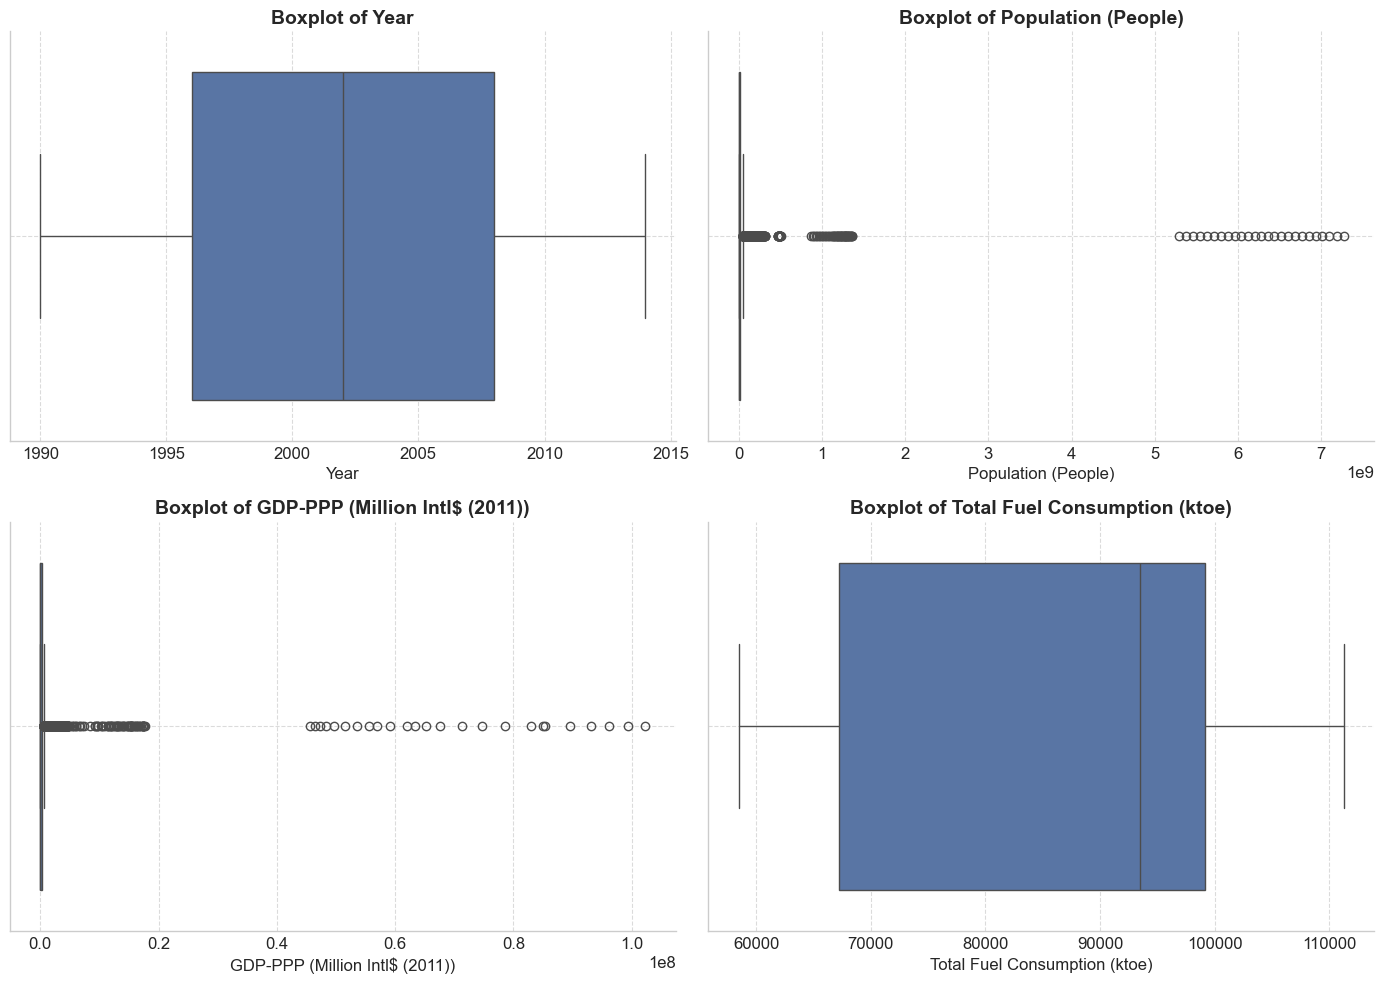

In [23]:
print("Boxplots to Detect Outliers")

numeric_cols = df.select_dtypes(include='number').columns
fig, axes = plt.subplots(2, 2, figsize=(14, 10)) 
axes = axes.flatten()  

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i] = tufte_plot(axes[i], f'Boxplot of {col}', col, '')

plt.tight_layout()
plt.show()

This code generates boxplots for each numeric column in the DataFrame `df` to help detect outliers. 
  
  Boxplots show the distribution, median, and potential outliers in each numeric feature.

Original rows: 4825, After outlier removal: 4023


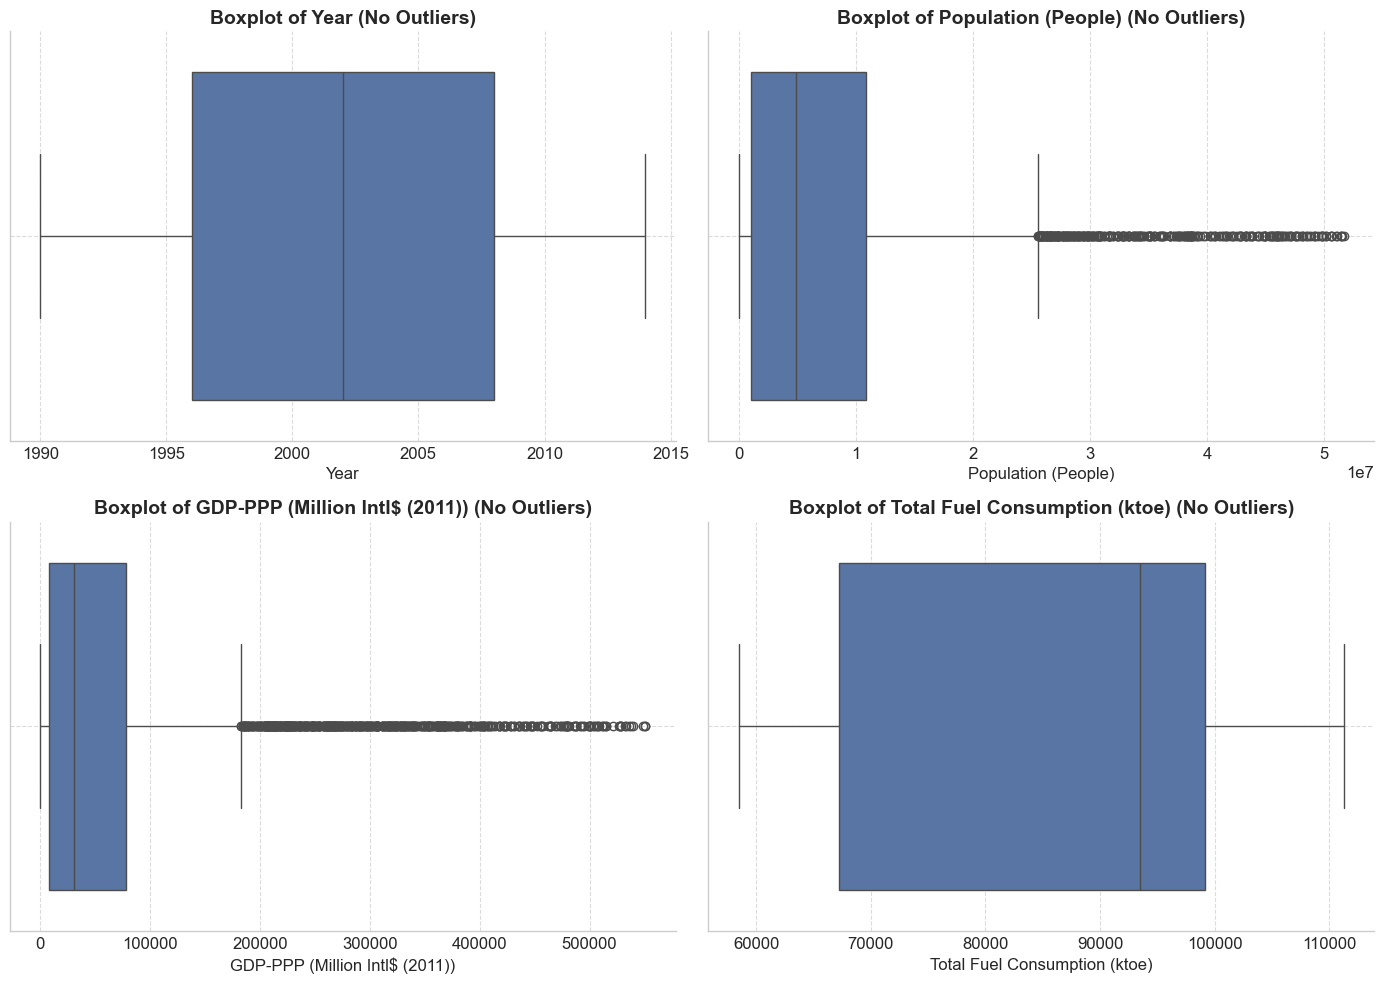

In [25]:
# Compute bounds for each numeric column
def remove_outliers_iqr(df, cols, k=1.5):
    mask = pd.Series(True, index=df.index)
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - k * IQR, Q3 + k * IQR
        # Keep rows where col is within [lower, upper]
        mask &= df[col].between(lower, upper)
    return df.loc[mask]

numeric_cols = df.select_dtypes(include='number').columns.tolist()

# Apply outlier removal
df_no_outliers = remove_outliers_iqr(df, numeric_cols)
print(f"Original rows: {df.shape[0]}, After outlier removal: {df_no_outliers.shape[0]}")

# plot Boxplots to Validate
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df_no_outliers[col], ax=axes[i])
    tufte_plot(axes[i], f'Boxplot of {col} (No Outliers)', col,'')

plt.tight_layout()
plt.show()



This code removes outliers from a dataset using the Interquartile Range (IQR) method, which filters out values that fall outside 1.5 times the IQR from the first and third quartiles. 

It applies this method to all numeric columns in the DataFrame and returns only rows where all values are within the acceptable range. After filtering, it prints how many rows remain to show the impact of outlier removal. It then creates boxplots for each numeric column to visually confirm that outliers have been successfully removed. Finally, the cleaned dataset replaces the original for further analysis or visualization.


Correlation Analysis


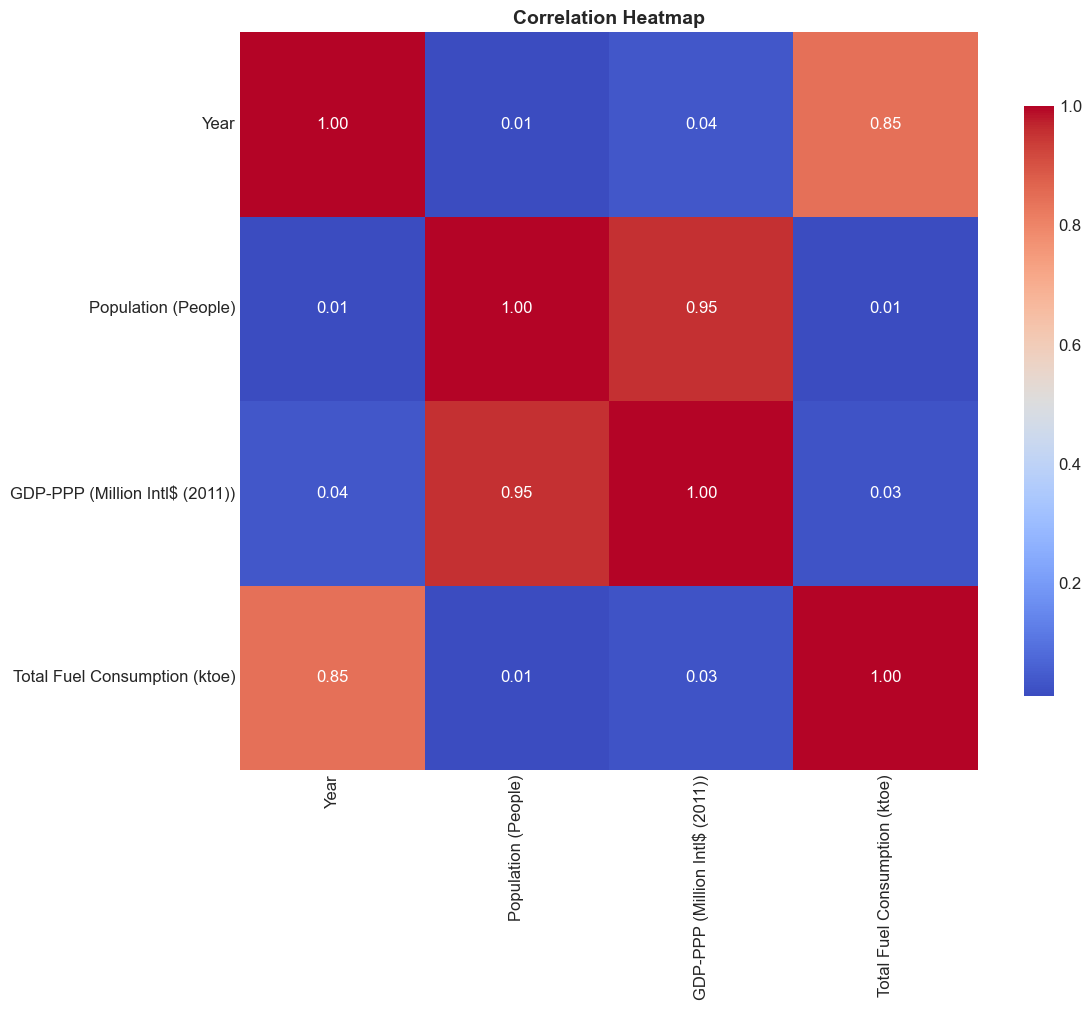

In [27]:
print("Correlation Analysis")
fig, ax = plt.subplots(figsize=(12, 10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax = tufte_plot(ax, 'Correlation Heatmap', '', '')
plt.tight_layout()
plt.show()


Correlation analysis of the numeric columns in the DataFrame df to understand how strongly they relate to each other. It calculates the correlation matrix and displays it as a heatmap using Seaborn, where color intensity and values indicate the strength and direction of relationships. 

The heatmap is styled with the tufte_plot function to enhance readability. This helps identify highly correlated features, which can inform feature selection.


## Inferential statistical 

I calculate a 95% confidence interval for the population mean of nations in the year 2000 as if the given nations are a sample from all nations in that year. I will also conduct a hypothesis test to compare the mean population of nations in 2000 with the mean in 2010 based on a two-sample t-test with the null hypothesis that the two means are equal.

#### Problem Statement
Estimate the average population of countries in 2000 at a confidence level of 95% and determine if the average populations in 2000 and 2010 are significantly different using Welch's t-test.

#### Observations
- **Confidence Interval**: Calculates the 95% confidence interval of the mean population in 2000 from sample mean, standard deviation, and z-score (1.96).
- **Hypothesis Test**: Uses Welch's t-test to compare 2000 and 2010 mean populations. Rejects null hypothesis (H₀: μ₂₀₀₀ = μ₂₀₁₀) when p-value < 0.05, indicating a difference.

#### Hypothesis Testing
- **Null Hypothesis (H₀)**: Mean populations for 2000 and 2010 are equal.
- **Alternative Hypothesis (H₁)**: Mean populations for 2000 and 2010 are equal.
- **Test**: Welch's t-test (unequal variances), α = 0.05.
- **Decision**: Reject H₀ whenever p-value < 0.05; otherwise, fail to reject.

In [13]:
# Filter for year 2000 and drop the EU‑28 row
sample2000 = (df['Year'] == 2000) & (df['Country'] != 'European Union (28)')
df2000 = df.loc[sample2000]

# Take just the first 32 rows (i.e. 32 countries) and turn Population into a list
populations_2000 = df2000['Population (People)'].iloc[:32].tolist()
print(populations_2000)

[3089027.0, 65390.0, 8011566.0, 9979610.0, 1728340.0, 3754986.0, 8342559.0, 15262754.0, 16686561.0, 11150736.0, 3392801.0, 811223.0, 10805808.0, 6524283.0, 1053050912.0, 211540429.0, 66131854.0, 23565413.0, 126843000.0, 84406.0, 390087.0, 3639592.0, 3030347.0, 38258629.0, 7516346.0, 44896856.0, 472390.0, 8872109.0, 6216205.0, 9699197.0, 3154925.0, 10531221.0]


For the year 2000, I selected the first 32 rows as the sample mean population. I divided the dataset into 6 parts, and these 32 rows represent the first part. This approach provides a better confidence interval.

In [14]:
# Filter for Year == 2010 and drop the EU‑28 aggregate
sample2010 = (df['Year'] == 2010) & (df['Country'] != 'European Union (28)')
df2010 = df.loc[sample2010]

# Grab the first 18 rows and convert Population to a list
populations_2010 = df2010['Population (People)'].iloc[:18].tolist()
print(populations_2010)

[8766930.0, 4448525.0, 11887202.0, 45918097.0, 4386693.0, 9897985.0, 9999617.0, 7623600.0, 7182390.0, 24591599.0, 3948125.0, 21151640.0, 7108239.0, 7291436.0, 5391428.0, 2048583.0, 12053223.0, 14086317.0]


For the year 2010, I selected the first 18 rows as the sample mean population. I divided the dataset into 10 parts, and these 18 rows represent the first part. This approach provides a better confidence interval.

In [15]:
from scipy import stats
# Confidence Interval for Mean Population in 2000
n_2000 = len(populations_2000)
mean_2000 = np.mean(populations_2000)
std_2000 = np.std(populations_2000, ddof=1)  # Sample standard deviation

confidence_level = 0.95
z = stats.norm.ppf(1 - (1 - confidence_level) / 2)  # Z-score for 95% confidence
margin_error = z * (std_2000 / np.sqrt(n_2000))

ci_lower = mean_2000 - margin_error
ci_upper = mean_2000 + margin_error

# Output Confidence Interval
print(f"\nConfidence Interval ({confidence_level*100:.0f}%) for Mean Population of Countries in 2000")
print(f"Mean: {mean_2000:.2f}")
print(f"Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")



Confidence Interval (95%) for Mean Population of Countries in 2000
Mean: 53671861.31
Confidence Interval: (-11221306.28, 118565028.91)


In [16]:
# Hypothesis Test: Comparing Mean Population in 2000 and 2010
t_stat, p_value = stats.ttest_ind(populations_2000, populations_2010)  # Welch's t-test
print(f"\nHypothesis Test: Comparing Mean Population of Countries in 2000 and 2010")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print("Conclusion")
if p_value < 0.05:
    print("Reject H₀: There is a significant difference in mean population.")
else:
    print("Fail to reject H₀: No significant difference in mean population.")



Hypothesis Test: Comparing Mean Population of Countries in 2000 and 2010
t-statistic: 0.9492
p-value: 0.3473
Conclusion
Fail to reject H₀: No significant difference in mean population.


## Inferential statistics for 6 tests

I selected three countries — Ireland, Denmark, and Finland — for the dataset df. I performed parametric statistical tests to compare their GDP-PPP per capita, after verifying the normality of the data using the Shapiro-Wilk test. This code supports both parametric and non-parametric tests.

In [17]:
from scipy.stats import shapiro

countries = ['Ireland', 'Denmark', 'Finland']
df_filtered = df[df['Country'].isin(countries)].copy()

# Calculate GDP-PPP per capita (in dollars per person)
df_filtered['gdp_per_capita'] = (df_filtered['GDP-PPP (Million Intl$ (2011))'] * 1e6) / df_filtered['Population (People)']

# Extract data for each country
ireland_gdp = df_filtered[df_filtered['Country'] == 'Ireland']['gdp_per_capita']
denmark_gdp = df_filtered[df_filtered['Country'] == 'Denmark']['gdp_per_capita']
finland_gdp = df_filtered[df_filtered['Country'] == 'Finland']['gdp_per_capita']

# Perform Shapiro-Wilk test to check normality
print("Normality Test (Shapiro-Wilk):")
print(f"Ireland: {shapiro(ireland_gdp)}")
print(f"Denmark: {shapiro(denmark_gdp)}")
print(f"Finland: {shapiro(finland_gdp)}")
print("(p > 0.05 indicates normality)")

Normality Test (Shapiro-Wilk):
Ireland: ShapiroResult(statistic=0.8558231949873449, pvalue=0.002276293488325073)
Denmark: ShapiroResult(statistic=0.8913635963306363, pvalue=0.011957046983158635)
Finland: ShapiroResult(statistic=0.8989251881696392, pvalue=0.0173851474145613)
(p > 0.05 indicates normality)


## Parametric tests

#### **Independent t-test**

#### **Problem Statement**
- The Independent t-test is used to determine the difference between Ireland and Denmark's mean GDP-PPP per capita. The aim is to ascertain if there exists a statistically significant difference in economic performance, based on GDP-PPP per capita, between Ireland and Denmark.

#### **Observations**
- The Independent t-test, Welch's t-test, is used to test the two independent groups' means assuming unequal variances.

#### **Hypothesis Testing**
- **Null Hypothesis (H₀)**: Irish mean GDP-PPP per capita equals the mean of Denmark.
- **Alternative Hypothesis (H₁)**: The mean GDP-PPP per capita for Ireland does not equal that for Denmark.
- **Decision Rule**: Fail to reject H₀: There is no statistically significant difference in means.

In [42]:
from scipy.stats import ttest_ind

# Independent t-test between Ireland and Denmark
t_stat, p_value_t = ttest_ind(ireland_gdp, denmark_gdp, equal_var=False)

# Display results
print("Test 1: Independent t-test")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value_t:.4f}")
print("H₀: The mean GDP-PPP per capita of Ireland is equal to that of Denmark.")
print("H₁: The mean GDP-PPP per capita of Ireland is not equal to that of Denmark.")
if p_value_t < 0.05:
    print("Reject H₀: There is a statistically significant difference in means.")
else:
    print("Fail to reject H₀: No statistically significant difference in means.")

Test 1: Independent t-test
t-statistic: -1.1453
p-value: 0.2607
H₀: The mean GDP-PPP per capita of Ireland is equal to that of Denmark.
H₁: The mean GDP-PPP per capita of Ireland is not equal to that of Denmark.
Fail to reject H₀: No statistically significant difference in means.


#### **ANOVA**

#### **Problem Statement**
The ANOVA (Analysis of Variance) test is performed to compare the mean GDP-PPP per capita across three countries—Ireland, Denmark, and Finland. The objective is to determine if there is a statistically significant difference in economic performance among these countries, indicating that at least one country’s mean differs from the others.

#### **Observations**
 ANOVA is suitable for comparing means across three or more independent groups.
  
#### **Hypothesis Testing**
- **Null Hypothesis (H₀)**: The mean GDP-PPP per capita is equal across Ireland, Denmark, and Finland (μ₁ = μ₂ = μ₃).
- **Alternative Hypothesis (H₁)**: At least one country’s mean GDP-PPP per capita differs from the others.
- **Decision Rule**: Reject H₀: At least one country has a different mean".


In [22]:
from scipy.stats import f_oneway

# ANOVA across Ireland, Denmark, and Finland
f_stat, p_value_anova = f_oneway(ireland_gdp, denmark_gdp, finland_gdp)

# Display results
print("Test 2: ANOVA")
print("Assumptions: Normality (checked), equal variances (to be checked with Levene's test), independence.")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value_anova:.4f}")
print("H₀: The mean GDP-PPP per capita is equal across Ireland, Denmark, and Finland.")
print("H₁: At least one country's mean differs.")
if p_value_anova < 0.05:
    print("Reject H₀: At least one country has a different mean.")
else:
    print("Fail to reject H₀: The means are equal across all three countries.")

Test 2: ANOVA
Assumptions: Normality (checked), equal variances (to be checked with Levene's test), independence.
F-statistic: 5.2755
p-value: 0.0073
H₀: The mean GDP-PPP per capita is equal across Ireland, Denmark, and Finland.
H₁: At least one country's mean differs.
Reject H₀: At least one country has a different mean.


#### **Z-test**

#### **Problem Statement**
The Z-test is employed to compare the mean GDP-PPP per capita between Ireland and Denmark. This test aims to determine if there is a statistically significant difference in economic performance between these two countries.

#### **Observations**
The Z-test is an alternative method for comparing two means, often applied in cases with large samples or known variances.

#### **Hypothesis Testing**
- **Null Hypothesis (H₀)**: The mean GDP-PPP per capita of Ireland is equal to that of Denmark (μ₁ = μ₂).
- **Alternative Hypothesis (H₁)**: The mean GDP-PPP per capita of Ireland is not equal to that of Denmark (μ₁ ≠ μ₂).
- **Decision Rule**: Fail to reject H₀: No statistically significant difference in means.


In [46]:
from statsmodels.stats.weightstats import ztest

# Independent z-test between Ireland and Denmark
z_stat, p_value_z = ztest(ireland_gdp, denmark_gdp)

# Display results
print("Test 3: z-test")
print(f"z-statistic: {z_stat:.4f}")
print(f"p-value: {p_value_z:.4f}")
print("H₀: The mean GDP-PPP per capita of Ireland is equal to that of Denmark.")
print("H₁: The mean GDP-PPP per capita of Ireland is not equal to that of Denmark.")
if p_value_z < 0.05:
    print("Reject H₀: There is a statistically significant difference in means.")
else:
    print("Fail to reject H₀: No statistically significant difference in means.")


Test 3: z-test
z-statistic: -1.1453
p-value: 0.2521
H₀: The mean GDP-PPP per capita of Ireland is equal to that of Denmark.
H₁: The mean GDP-PPP per capita of Ireland is not equal to that of Denmark.
Fail to reject H₀: No statistically significant difference in means.


z-test is justified here as it compares the means of two large, independent samples (Ireland and Denmark), assuming approximate normality and equal or known variances. It helps determine whether the observed difference in GDP-PPP per capita between the two countries is statistically significant.


## Non-Parametric Tests

#### **Mann-Whitney U Test**

#### **Problem Statement**
The Mann-Whitney U test is conducted to compare the distributions of GDP-PPP per capita between Ireland and Denmark. This test aims to determine if there is a statistically significant difference in the economic performance distributions between these two countries, without requiring the assumption of normality.

#### **Observations**
- The Mann-Whitney U test is a non-parametric test designed for comparing two independent groups when the data may not follow a normal distribution.
- It assesses whether the distributions of the two groups differ, rather than specifically comparing means.

#### **Hypothesis Testing**
- **Null Hypothesis (H₀)**: The distributions of GDP-PPP per capita are equal between Ireland and Denmark.
- **Alternative Hypothesis (H₁)**: The distributions of GDP-PPP per capita differ between Ireland and Denmark.
- **Decision**: Fail to reject H₀: The distributions of GDP-PPP per capita are equal between Ireland and Denmark..

In [50]:
from scipy.stats import mannwhitneyu

# Mann-Whitney U test between Ireland and Denmark
u_stat, p_value_mw = mannwhitneyu(ireland_gdp, denmark_gdp)

# Display results
print("Test 4: Mann-Whitney U test")
print(f"U-statistic: {u_stat:.4f}")
print(f"p-value: {p_value_mw:.4f}")
print("H₀: The distributions of GDP-PPP per capita are equal between Ireland and Denmark.")
print("H₁: The distributions differ.")
if p_value_mw < 0.05:
    print("Reject H₀: The distributions differ.")
else:
    print("Fail to reject H₀: The distributions are equal.")

Test 4: Mann-Whitney U test
U-statistic: 327.0000
p-value: 0.7859
H₀: The distributions of GDP-PPP per capita are equal between Ireland and Denmark.
H₁: The distributions differ.
Fail to reject H₀: The distributions are equal.


#### **Kruskal-Wallis Test**

#### **Problem Statement**
The Kruskal-Wallis test is performed to compare the distributions of GDP-PPP per capita across three countries: Ireland, Denmark, and Finland. This test seeks to determine if there is a statistically significant difference in the economic performance distributions among these countries, without assuming normality.

#### **Observations**
- The Kruskal-Wallis test is a non-parametric alternative to ANOVA, suitable for comparing more than two independent groups.
- It tests for differences in the distributions across groups, not specifically means, making it robust to non-normal data.

#### **Hypothesis Testing**
- **Null Hypothesis (H₀)**: The distributions of GDP-PPP per capita are equal across Ireland, Denmark, and Finland.
- **Alternative Hypothesis (H₁)**: At least one country’s distribution of GDP-PPP per capita differs from the others.
- **Decision**: Reject H₀: At least one country's distribution of GDP-PPP per capita differs from the others.


In [52]:
from scipy.stats import kruskal

# Kruskal-Wallis test across Ireland, Denmark, and Finland
k_stat, p_value_kw = kruskal(ireland_gdp, denmark_gdp, finland_gdp)

# Display results
print("Test 5: Kruskal-Wallis test")
print(f"K-statistic: {k_stat:.4f}")
print(f"p-value: {p_value_kw:.4f}")
print("H₀: The distributions of GDP-PPP per capita are equal across Ireland, Denmark, and Finland.")
print("H₁: At least one country's distribution differs.")
if p_value_kw < 0.05:
    print("Reject H₀: At least one country has a different distribution.")
else:
    print("Fail to reject H₀: The distributions are equal.")

Test 5: Kruskal-Wallis test
K-statistic: 11.9510
p-value: 0.0025
H₀: The distributions of GDP-PPP per capita are equal across Ireland, Denmark, and Finland.
H₁: At least one country's distribution differs.
Reject H₀: At least one country has a different distribution.


#### **Chi-squared Test**

#### **Problem Statement**
The Chi-squared test is used to examine whether the distribution of GDP-PPP per capita categories (low, medium, high) differs by country (Ireland, Denmark, Finland). This test assesses whether the proportions of these categories are independent of the country, based on a contingency table created from categorized GDP data.

#### **Observations**
- The Chi-squared test is appropriate for categorical data and tests for independence between two variables—here, country and GDP category (low, medium, high).
- The continuous GDP-PPP per capita data is categorized into low, medium, and high based on quantiles (33rd and 66th percentiles), enabling the application of this test.

#### **Hypothesis Testing**
- **Null Hypothesis (H₀)**: The distribution of GDP-PPP per capita categories is independent of the country (i.e., the proportions of low, medium, and high categories are the same across countries).
- **Alternative Hypothesis (H₁)**: The distribution of GDP-PPP per capita categories depends on the country (i.e., the proportions differ across countries).
- **Decision**: Reject H₀: The distribution of GDP-PPP per capita categories depends on the country (i.e., the proportions differ across countries).



In [54]:
from scipy.stats import chi2_contingency

# Define categories based on quantiles
overall_gdp = df_filtered['gdp_per_capita']
low_threshold = overall_gdp.quantile(0.33)
high_threshold = overall_gdp.quantile(0.66)
df_filtered['category'] = pd.cut(df_filtered['gdp_per_capita'], bins=[-np.inf, low_threshold, high_threshold, np.inf], labels=['low', 'medium', 'high'])

# Create contingency table
contingency_table = pd.crosstab(df_filtered['Country'], df_filtered['category'])

# Perform Chi-squared test
chi2, p_value_chi, dof, ex = chi2_contingency(contingency_table)

# Display results
print("Test 6: Chi-squared test")
print(f"Chi-squared: {chi2:.4f}")
print(f"p-value: {p_value_chi:.4f}")
print("H₀: The distribution of GDP-PPP per capita categories is independent of country.")
print("H₁: The distribution depends on country.")
if p_value_chi < 0.05:
    print("Reject H₀: The distribution depends on the country.")
else:
    print("Fail to reject H₀: The distribution is independent of country.")

Test 6: Chi-squared test
Chi-squared: 24.9008
p-value: 0.0001
H₀: The distribution of GDP-PPP per capita categories is independent of country.
H₁: The distribution depends on country.
Reject H₀: The distribution depends on the country.
